In [389]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3



from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import confusion_matrix,  accuracy_score, classification_report

import warnings
from warnings import filterwarnings
filterwarnings("ignore")

**Data Collection**

---Data is imported from SQL database file (.sqlite)






In [390]:
con = sqlite3.connect(r"password_data.sqlite")
data = pd.read_sql_query("SELECT * FROM Users" , con)
data.head(4)

,index,password,strength
0,0,zxe870819,1
1,1,xw46454nr23l,1
2,2,soporte13,1
3,3,accounts6000webhost.com,2


In [391]:
data.shape

(100000, 3)

**Data Cleaning**


---Data cleaning is a crucial stage before performing any analysis since the dataframe might contain duplicates, missing values, or irrelevant rows.



In [392]:
data.drop(["index"] , axis=1 , inplace=True)

In [393]:

data.duplicated().sum()

np.int64(0)

In [394]:
data.isnull().any()

,0
password,False
strength,False


In [395]:
data.isnull().sum()

,0
password,0
strength,0


In [396]:
data.dtypes

,0
password,object
strength,int64


In [397]:
data['strength'].unique()

array([1, 2, 0])

I removed the index columns since the dataframe already has an index. Additionally, I checked for any duplicated or missing values in the columns. After that, I reviewed all the data types for each feature and verified that the strength column only had values of 0, 1, or 2.

**Performing Semantic Analysis**

---Below is an example of a question regarding the textual password in our dataset:



*       How many password textual actually holds only numeric characters ?
*       How many password textual actually holds only Upper-case character ?
*       How many password textual actually holds only alphabet ?
*       How many password textual actually holds alpha-numeric character ?
*       How many password textual actually holds title-case character ?
*       How many password textual actually holds some special special character ?





In [398]:
data.columns

Index(['password', 'strength'], dtype='object')

In [399]:
data["password"]


,password
0,zxe870819
1,xw46454nr23l
2,soporte13
3,accounts6000webhost.com
4,c443balg
...,...
99995,obejofi215
99996,fmiopvxb64
99997,czvrbun38
99998,mymyxe430


## How many password holds only numeric characters ?

In [400]:
data["password"].str.isnumeric()

,password
0,False
1,False
2,False
3,False
4,False
...,...
99995,False
99996,False
99997,False
99998,False


In [401]:
data[data["password"].str.isnumeric()]


,password,strength
12280,943801,0
14992,12345,0
20958,147856,0
21671,140290,0
23269,123987,0
28569,1233214,0
31329,0159456,0
32574,363761,0
37855,4524344,0
43648,5521597,0


In [402]:
data[data["password"].str.isnumeric()].shape

(26, 2)

## How many password holds only Upper-case characters ?

In [403]:
data[data["password"].str.isupper()]

,password,strength
115,EYT63119,1
273,INSPIRON6,1
338,1A2S3D4F,1
367,13269123A,1
373,YAMAZAKI82,1
...,...,...
99590,V13000993J,1
99692,65925013ABC,1
99784,01EDD055,1
99893,1UPONYOU,1


In [404]:
data[data["password"].str.isupper()].shape

(1506, 2)

## How many password holds only alphabets?

In [405]:
data[data["password"].str.isalpha()]

,password,strength
267,PomarancaÇ,1
1380,smgodt,0
3198,cuado,0
4560,jelsz,0
6380,demsxp,0
7803,secret,0
9218,caballo,0
11555,mhe,0
11667,kreedo,0
13645,nõmlich,0


In [406]:
data[data["password"].str.isalpha()].shape

(50, 2)

## How many password holds only alpha-numeric characters?

In [407]:
data[data["password"].str.isalnum()]

,password,strength
0,zxe870819,1
1,xw46454nr23l,1
2,soporte13,1
4,c443balg,1
5,16623670p,1
...,...,...
99995,obejofi215,1
99996,fmiopvxb64,1
99997,czvrbun38,1
99998,mymyxe430,1


In [408]:
data[data["password"].str.isalnum()].shape

(97203, 2)

## How many password holds only title-case characters?

In [409]:
data[data["password"].str.istitle()]

,password,strength
64,Hisanthoshjasika0,2
242,Therockrockbottom72,2
338,1A2S3D4F,1
367,13269123A,1
526,Csicskarozsika1,2
...,...,...
99168,1053815198M,1
99192,Alfranx05122023,2
99375,Kensington1956,2
99590,V13000993J,1


In [410]:
data[data["password"].str.istitle()].shape

(932, 2)

## How many password holds special characters?

In [411]:
data["password"]

,password
0,zxe870819
1,xw46454nr23l
2,soporte13
3,accounts6000webhost.com
4,c443balg
...,...
99995,obejofi215
99996,fmiopvxb64
99997,czvrbun38
99998,mymyxe430


In [412]:
import string

In [413]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [414]:
def find_special_chars(row):
    for char in row:
        if char in string.punctuation:
            return 1
        else:
            pass


In [415]:
data["password"].apply(find_special_chars)==1

,password
0,False
1,False
2,False
3,True
4,False
...,...
99995,False
99996,False
99997,False
99998,False


In [416]:
data[data["password"].apply(find_special_chars)==1]

,password,strength
3,accounts6000webhost.com,2
68,12463773800+,1
98,p.r.c.d.g.,1
145,cita-cita,1
180,karolina.susnina0U,2
...,...,...
99748,maiselis.com,1
99845,hosting4meze!@#,2
99954,semista_bakung15,2
99980,halflife2010!LEB,2


In [417]:
data[data["password"].apply(find_special_chars)==1].shape

(2663, 2)

**Analysis**



1.   Only 26 people have set their password only with numbers
2.   Around 1500 users have their password as only capital letters
3.   50 users have their password with alphabet letters only
4.   Most of the users around 97k have their password as alpha-numeric
5.   932 users have their password having first alphabet capital
6.   2663 people set their password with at least one special character



**Feature Engineering**

Password strength depends on 5 factors :

*   Length of password
*   Frequency of Lowercase Characters
*   Frequency of Uppercase Characters
*   Frequency of Numeric Characters
*   Frequency of Special Characters



Length of password

In [418]:
data['length'] = data.password.str.len()
data.head()

,password,strength,length
0,zxe870819,1,9
1,xw46454nr23l,1,12
2,soporte13,1,9
3,accounts6000webhost.com,2,23
4,c443balg,1,8


Frequency of LowerCase Characters

In [419]:
def lower_case_freq(row):
    return len([char for char in row if char.islower()])/len(row)


In [420]:
data['lower_freq'] = np.round(data['password'].apply(lower_case_freq),3)

In [421]:
data

,password,strength,length,lower_freq
0,zxe870819,1,9,0.333
1,xw46454nr23l,1,12,0.417
2,soporte13,1,9,0.778
3,accounts6000webhost.com,2,23,0.783
4,c443balg,1,8,0.625
...,...,...,...,...
99995,obejofi215,1,10,0.700
99996,fmiopvxb64,1,10,0.800
99997,czvrbun38,1,9,0.778
99998,mymyxe430,1,9,0.667


Frequency of UpperCase Characters

In [422]:
def upper_case_freq(row):
    return len([char for char in row if char.isupper()])/len(row)


In [423]:
data['upper_freq'] = np.round(data['password'].apply(upper_case_freq),3)


In [424]:
data

,password,strength,length,lower_freq,upper_freq
0,zxe870819,1,9,0.333,0.0
1,xw46454nr23l,1,12,0.417,0.0
2,soporte13,1,9,0.778,0.0
3,accounts6000webhost.com,2,23,0.783,0.0
4,c443balg,1,8,0.625,0.0
...,...,...,...,...,...
99995,obejofi215,1,10,0.700,0.0
99996,fmiopvxb64,1,10,0.800,0.0
99997,czvrbun38,1,9,0.778,0.0
99998,mymyxe430,1,9,0.667,0.0


Frequency of Numeric Characters

In [425]:
def numeric_freq(row):
    return len([char for char in row if char.isdigit()])/len(row)


In [426]:
data['digit_freq'] = np.round(data['password'].apply(numeric_freq),3)

In [427]:
data

,password,strength,length,lower_freq,upper_freq,digit_freq
0,zxe870819,1,9,0.333,0.0,0.667
1,xw46454nr23l,1,12,0.417,0.0,0.583
2,soporte13,1,9,0.778,0.0,0.222
3,accounts6000webhost.com,2,23,0.783,0.0,0.174
4,c443balg,1,8,0.625,0.0,0.375
...,...,...,...,...,...,...
99995,obejofi215,1,10,0.700,0.0,0.300
99996,fmiopvxb64,1,10,0.800,0.0,0.200
99997,czvrbun38,1,9,0.778,0.0,0.222
99998,mymyxe430,1,9,0.667,0.0,0.333


Frequency of Special Characters

In [428]:
def special_chars_freq(row):
    special_chars =[]
    for char in row:
        if not char.isalpha() and not char.isdigit():
            special_chars.append(char)
    return len(special_chars)/len(row)

In [429]:
data['special_char_freq'] = np.round(data['password'].apply(special_chars_freq),3)


In [430]:
data

,password,strength,length,lower_freq,upper_freq,digit_freq,special_char_freq
0,zxe870819,1,9,0.333,0.0,0.667,0.000
1,xw46454nr23l,1,12,0.417,0.0,0.583,0.000
2,soporte13,1,9,0.778,0.0,0.222,0.000
3,accounts6000webhost.com,2,23,0.783,0.0,0.174,0.043
4,c443balg,1,8,0.625,0.0,0.375,0.000
...,...,...,...,...,...,...,...
99995,obejofi215,1,10,0.700,0.0,0.300,0.000
99996,fmiopvxb64,1,10,0.800,0.0,0.200,0.000
99997,czvrbun38,1,9,0.778,0.0,0.222,0.000
99998,mymyxe430,1,9,0.667,0.0,0.333,0.000


**Data Analysis**

In [431]:
data.columns

Index(['password', 'strength', 'length', 'lower_freq', 'upper_freq',
       'digit_freq', 'special_char_freq'],
      dtype='object')

In [432]:
data[['length','strength']].groupby(['strength']).agg(['min','max','mean','median'])

length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0

In [433]:
cols = ['length', 'lower_freq', 'upper_freq','digit_freq', 'special_char_freq']

for col in cols:
    print(col)
    print(data[[col,'strength']].groupby(['strength']).agg(['min','max','mean','median']))
    print('\n')


length
         length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0


lower_freq
         lower_freq                        
                min    max      mean median
strength                                   
0               0.0  1.000  0.708050  0.714
1               0.0  0.923  0.630067  0.667
2               0.0  0.917  0.424679  0.400


upper_freq
         upper_freq                        
                min    max      mean median
strength                                   
0               0.0  1.000  0.012872  0.000
1               0.0  0.923  0.007915  0.000
2               0.0  0.889  0.367633  0.429


digit_freq
         digit_freq                        
                min    max      mean median
strength                                   
0               0.0  1.000  0.275383  0.286
1               

# to delve further into the data by utilizing visualization techniques, specifically creating a box plot.

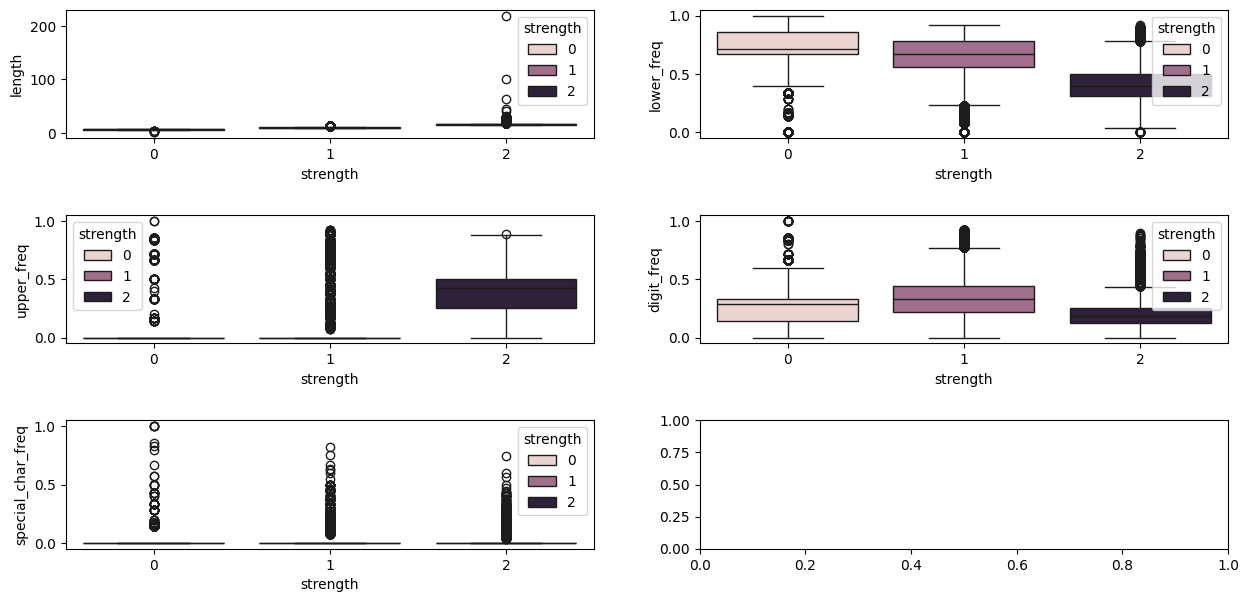

In [434]:
fig , ((ax1 , ax2) , (ax3 , ax4) , (ax5,ax6)) = plt.subplots(3 , 2 , figsize=(15,7))

sns.boxplot(x="strength" , y='length' , hue="strength" , ax=ax1 , data=data)
sns.boxplot(x="strength" , y='lower_freq' , hue="strength" , ax=ax2, data=data)
sns.boxplot(x="strength" , y='upper_freq' , hue="strength" , ax=ax3, data=data)
sns.boxplot(x="strength" , y='digit_freq' , hue="strength" , ax=ax4, data=data)
sns.boxplot(x="strength" , y='special_char_freq' , hue="strength" , ax=ax5, data=data)

plt.subplots_adjust(hspace=0.6)
plt.show()



*   Higher Lowercase frequency is seen in low strength passwords. For higher strength passwords, Lowercase frequency can be high too but that is probably effect of length.
*   In digit_freq there is a split of majority poplutation of strength 1 and 2 but for 0 and 1 strength, there is overlap so not too much to say there. But we can say a nicely proportioned password is good.
*    In upper_freq, there is a trend but not as strong as length or lower_freq.
*    Similar but stronger same trend as above in special_freq



**Feature Importance**

Univariate Analysis tests one variable at a time. We use a Violin Plot which is a combination of a box and distribution plot.

In [435]:
def get_dist(data , feature):

    plt.figure(figsize=(10,8))
    plt.subplot(1,2,1)

    sns.violinplot(x='strength' , y=feature , data=data )

    plt.subplot(1,2,2)

    sns.distplot(data[data['strength']==0][feature] , color="red" , label="0" , hist=False)
    sns.distplot(data[data['strength']==1][feature], color="blue", label="1", hist=False)
    sns.distplot(data[data['strength']==2][feature], color="orange", label="2", hist=False)
    plt.legend()
    plt.show()

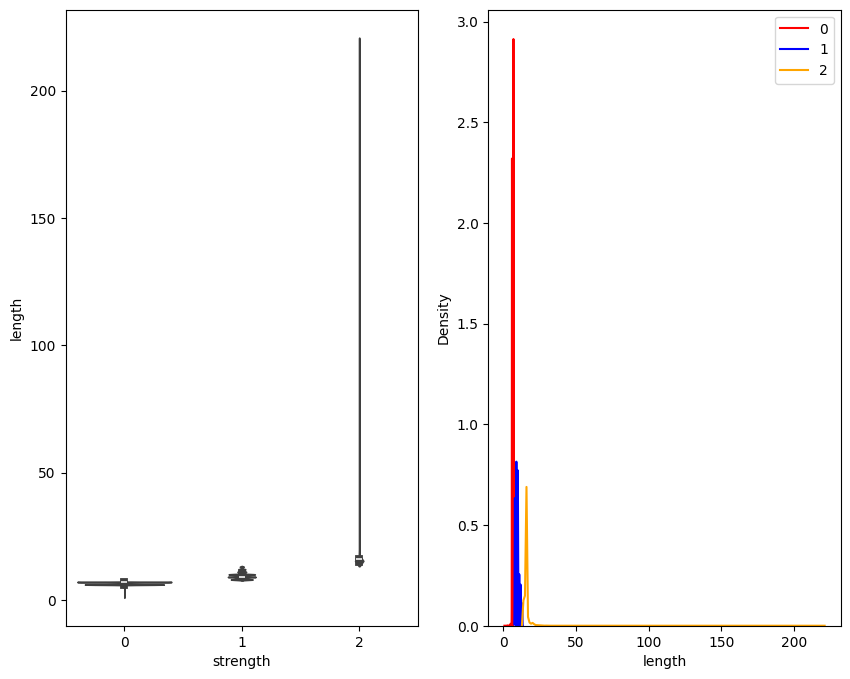

In [436]:
get_dist(data, "length")

We have a few overlapping regions in the distribution plot. When class is 2, we have a higher value of ‘length’ than class 1 & class 0. It means ‘length’ is an interesting feature as we have very little overlapping region. Similarly from the violin plot, we will say on account of less overlapping. This feature ‘length’ is amazing & useful in determining the strength.

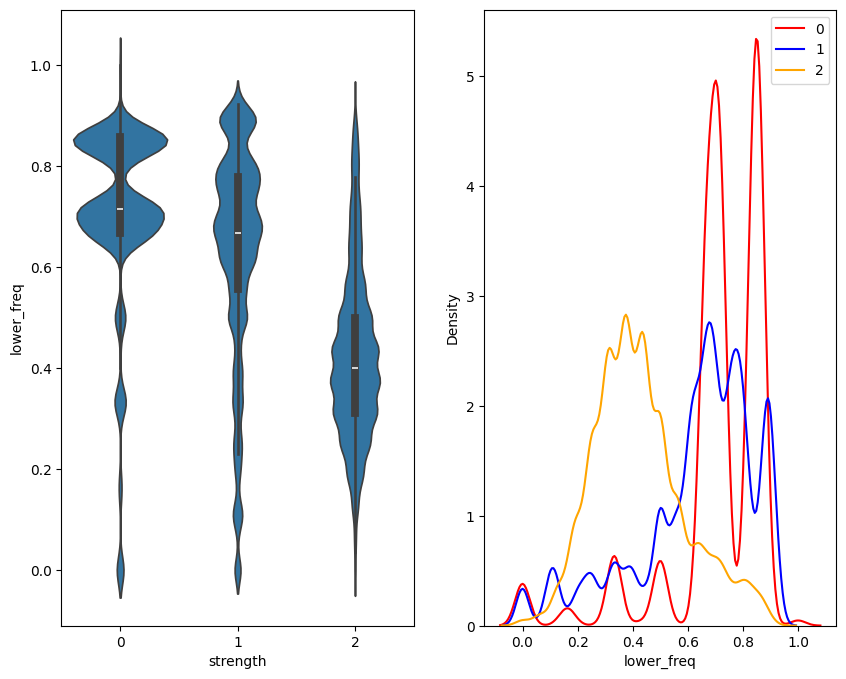

In [437]:
get_dist(data,'lower_freq')

We have some kind of overlapping regions in the distribution ploy. When class is 2, we have less value of ‘lower_freq’ than class 1 and 0. It implies that ‘lower_freq’ is an interesting feature up to some extent. Similarly from the violin plot, we will say on account of such overlapping. When class is 2, we have less value of ‘lower_freq’ than class 1 and 0.


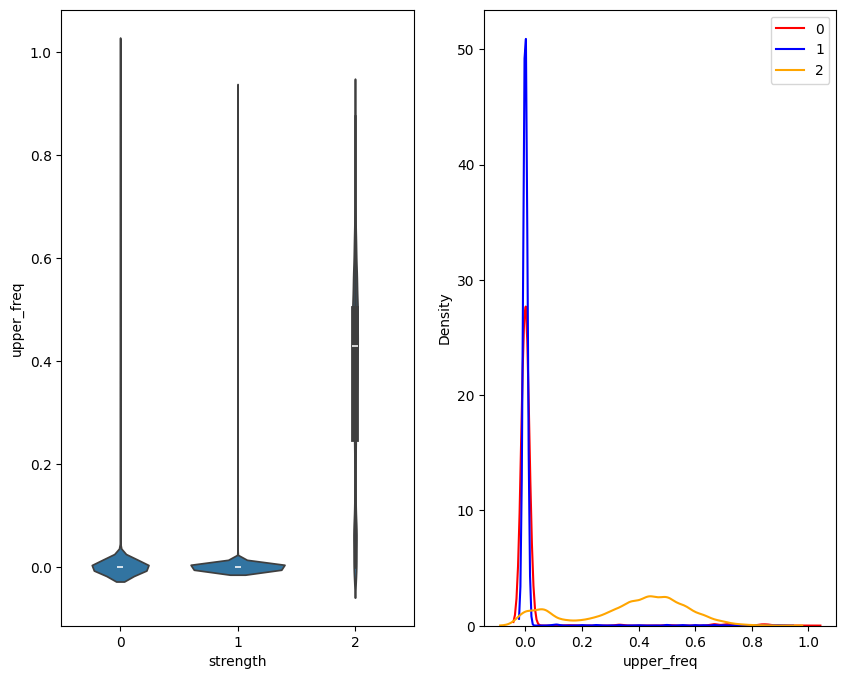

In [438]:
get_dist(data,'upper_freq')


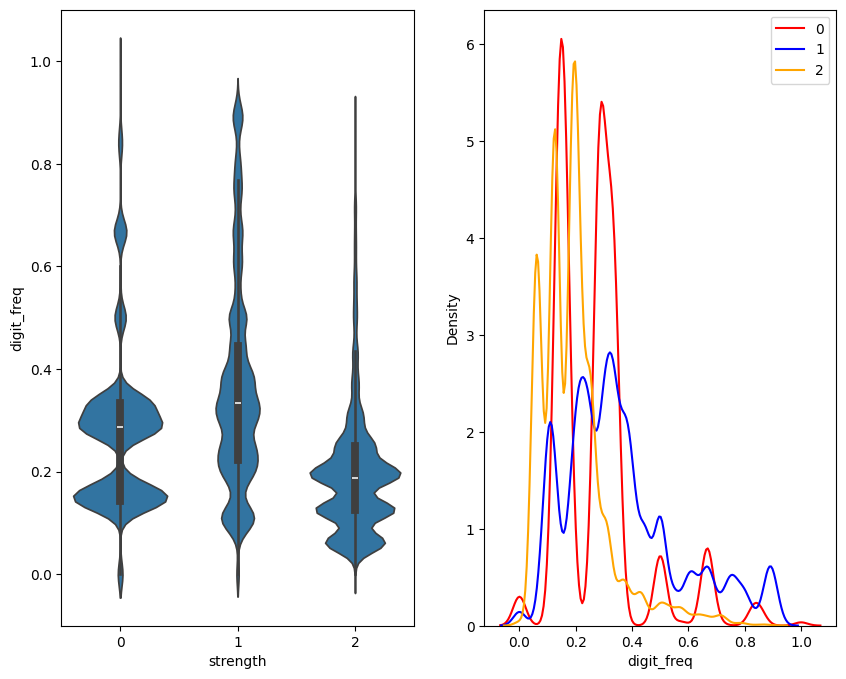

In [439]:
get_dist(data,'digit_freq')

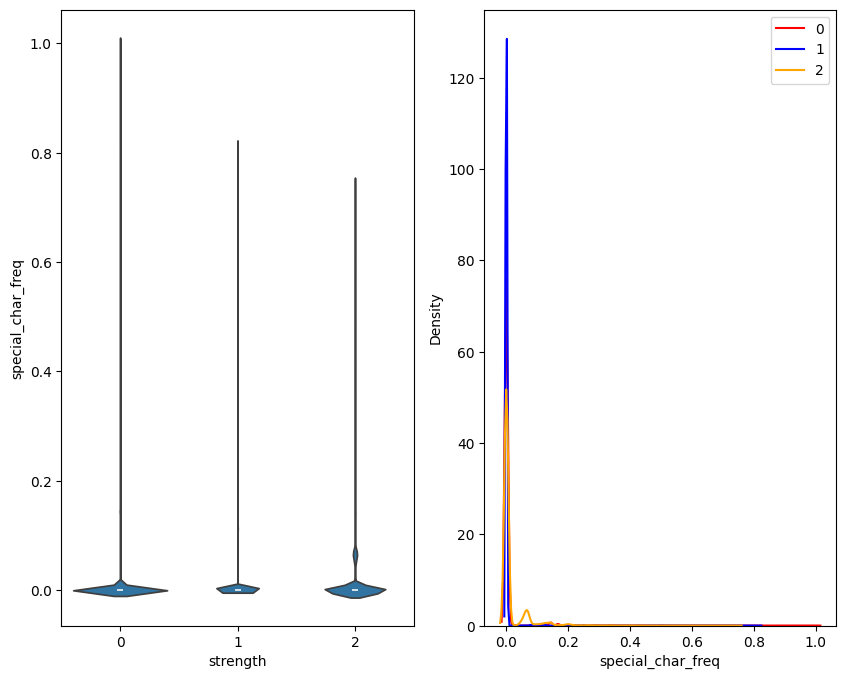

In [440]:
get_dist(data,'special_char_freq')

Based on the distribution and violin plots, I have observed that the last three features overlap significantly with each other, and there is no distinct variation between them. Therefore, I have concluded that these features are not significant and should not be considered as inputs for the machine learning model.

**Applying TF_IDF on data**

To ensure the robustness of a machine learning model, it is recommended to shuffle the data.

TF-IDF vectorizer is a tool that converts text data into numerical data. When dealing with passwords, which are a series of characters, we need to calculate the TF-IDF values for each individual character. To accomplish this, we first split the password into a list of its constituent characters. Then, we create a matrix X, where each row corresponds to a single password and each of the 99 columns represents a unique character, digit, or special character that could appear in a password.

In [441]:
dataframe = data.sample(frac=1)

In [442]:
dataframe

,password,strength,length,lower_freq,upper_freq,digit_freq,special_char_freq
79138,qwert2468,1,9,0.556,0.000,0.444,0.0
1789,GbiMafTc4MAt3yKw,2,16,0.500,0.375,0.125,0.0
70309,division10,1,10,0.800,0.000,0.200,0.0
48693,d02071522,1,9,0.111,0.000,0.889,0.0
27546,dezy34,0,6,0.667,0.000,0.333,0.0
...,...,...,...,...,...,...,...
96006,zanetox111,1,10,0.700,0.000,0.300,0.0
24739,mqoitsnb2,1,9,0.889,0.000,0.111,0.0
4817,panchito96,1,10,0.800,0.000,0.200,0.0
76833,94384302wajdi,1,13,0.385,0.000,0.615,0.0


In [443]:
x = list(dataframe["password"])

In [444]:
vectorizer = TfidfVectorizer(analyzer = "char")

In [445]:
X = vectorizer.fit_transform(x)

In [446]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 842571 stored elements and shape (100000, 99)>

In [447]:
X.toarray()[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.26732636, 0.        , 0.33058693,
       0.        , 0.35069181, 0.        , 0.33825704, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.26067243, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.42148196, 0.29641153,
       0.        , 0.3155506 , 0.        , 0.        , 0.38576831,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [448]:
vectorizer.get_feature_names_out()

array(['\x04', '\x06', '\x08', '\x0e', '\x10', '\x11', '\x17', ' ', '!',
       '#', '$', '%', '&', '(', ')', '*', '+', '-', '.', '/', '0', '1',
       '2', '3', '4', '5', '6', '7', '8', '9', ';', '<', '=', '>', '?',
       '@', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f',
       'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's',
       't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~', '¡', '¨',
       '°', '±', '³', '´', 'µ', '·', 'ß', 'à', 'á', 'ä', 'æ', 'ç', 'é',
       'ê', 'í', 'ñ', 'ó', 'õ', 'ö', '÷', 'ú', 'ü', 'ý', 'þ', '›'],
      dtype=object)

In [449]:
df =pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

In [450]:
df

,,,,,,,,,!,#,...,ñ,ó,õ,ö,÷,ú,ü,ý,þ,›
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We create a new dataframe with rows for all 100000 passwords and columns for all 99 characters like the below image.

In [451]:
df['length'] = dataframe['length']
df['lower_freq'] = dataframe['lower_freq']

In [452]:
df

,,,,,,,,,!,#,...,õ,ö,÷,ú,ü,ý,þ,›,length,lower_freq
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.333
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12,0.417
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.778
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,0.783
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,0.700
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,0.800
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.778
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.667


**Applying Machine Learning Algorithm**

In [453]:
y = dataframe['strength']

In [459]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.20)

In [460]:
X_train.shape

(80000, 101)

In [461]:
y_train.shape

(80000,)

In [462]:
clf = LogisticRegression(multi_class ="multinomial")

In [463]:
clf.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial')

After splitting the dataset into 80% for training and 20% for testing, I used multinomial logistic regression to classify strength into three categories: 0, 1, and 2.

**Prediction on Sample Data**

In [464]:
password ="%.@123abmµcd"

In [465]:
sample_array = np.array([password])
sample_matrix = vectorizer.transform(sample_array)

In [466]:
sample_matrix.toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.48468167, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.32786242, 0.        ,
        0.        , 0.09670039, 0.11187767, 0.12530347, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.32857835, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.09312595, 0.1561144 , 0.14586478,
        0.14026689, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.12869972,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [467]:
password

'%.@123abmµcd'

In [468]:
len(password)

12

In [469]:
len([char for char in password if char.islower()]) / len(password)

0.5

In [470]:
values_to_append = np.array([[12, 0.5]])

In [471]:
np.append(sample_matrix.toarray(),(12,0.5))

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.48468167,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.32786242,  0.        ,
        0.        ,  0.09670039,  0.11187767,  0.12530347,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.32857835,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.09312595,  0.1561144 ,  0.14586478,
        0.14026689,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.12869972,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [472]:
np.append(sample_matrix.toarray(),values_to_append).shape

(101,)

As the Logistic regression model 'clf' was trained on 101 features - 99 from TF-IDF and 2 from (total_length+lower_case_freq) - any input (password) needs to be converted into (1,101) so that the model can accept it as input.

In [473]:
np.append(sample_matrix.toarray(),values_to_append).shape

(101,)

In [475]:
def predict():
    password = input("Enter a password : ")
    sample_array = np.array([password])
    sample_matrix = vectorizer.transform(sample_array)
    length_pass = len(password)
    length_normalised_lowercase = len([char for char in password if char.lower()])/len(password)
    new_matrix2 = np.append(sample_matrix.toarray(), (length_pass, length_normalised_lowercase)).reshape(1,101)
    result  = clf.predict(new_matrix2)
    if result == 0:
        return "Password is weak"
    elif result == 1:
        return "Password is normal"
    else:
        return "Password is strong"

In [476]:
predict()

Enter a password : @olmp.218*,hvxroirfdsw<$


'Password is strong'

In [477]:
predict()

Enter a password : kl12m


'Password is normal'

**Model Evaluation**

In [478]:
y_pred = clf.predict(X_test)

In [479]:
accuracy_score(y_test , y_pred)

0.803

In [480]:
confusion_matrix(y_test , y_pred)

array([[  726,  2077,     1],
       [  530, 13929,   267],
       [   72,   993,  1405]])

In [481]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.55      0.26      0.35      2804
           1       0.82      0.95      0.88     14726
           2       0.84      0.57      0.68      2470

    accuracy                           0.80     20000
   macro avg       0.74      0.59      0.64     20000
weighted avg       0.78      0.80      0.78     20000



## The model accurately predicts password levels 1 and 2 but performs poorly on weak passwords.


In [483]:
from joblib import dump
dump(clf, 'LG.joblib')

['LG.joblib']